# Multi-scale energy systems modeling and optimization example in energiapy


__author__ = "Rahul Kakodkar"
__copyright__ = "Copyright 2022, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"


$\textbf{Import modules}$

In [1]:
import pandas
from numpy import poly1d, polyfit
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result
from src.energiapy.model.formulate_milp import formulate_milp
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from src.energiapy.plot import plot
from src.energiapy.model.pyomo_solve import solve
from src.energiapy.utils.cluster_utils import reduce_scenario, agg_hierarchial_elbow, Clustermethod
from src.energiapy.utils.data_utils import load_results
import matplotlib.pyplot as plt


**Import solar dni and wind speeds for Harris county**

Data was collected using the fetch_nsrdb_data function from energiapy.utils for data point with maximum elevation in Harris county

In [8]:
ho_solar_df = pandas.read_csv('data/ho_solar.csv', index_col=0) #Houston solar dni
ho_wind_df = pandas.read_csv('data/ho_wind.csv', index_col=0) #Houston wind speeds

In [9]:
ho_solar_df

,dni
2019-01-01 00:00:00,0.0
2019-01-01 01:00:00,0.0
2019-01-01 02:00:00,0.0
2019-01-01 03:00:00,0.0
2019-01-01 04:00:00,0.0
...,...
2019-12-31 19:00:00,301.5
2019-12-31 20:00:00,16.0
2019-12-31 21:00:00,42.0
2019-12-31 22:00:00,9.5


**Import natural gas prices from Henry Hub Price Index**

Natural gas prices are from the Henry price index at a daily temporal resolution. 

The energia.make_henry_price_df function implicitly fills in gaps in data such as weekends and public holidays by repeating the last recorded prices
For e.g. if the 4th of July will use the price for the 3rd of July
a typical saturday and sunday will take the values for the last friday.

The stretch functionality stretches the values over the hourly temporal scale (8760) from a daily temporal scale (365), again through repetition.  

In [3]:
hp_price_daily_df = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2019, stretch=True)

**import cost data**

The costing data for Lithium ion batteries, Solar PVs, Wind Farms, and pumped storage hydropower (PSH) are from the NREL annual technology baseline 2021

The rest of the costing data is from assorted sources as stated

Technology costs have three components: Capital expenditure (CAPEX), fixed operation and management expenditure (Fixed O&M), and variable operation and management expenditure (Variable O&M)

The costing is done with respect to a defined basis for each process. 

Note that this is done for the sake of ease, the prices can also be introduced directly to a process class object

In [4]:
cost_dict = get_data(file_name='data/cost_dict')
for i in cost_dict['HO']['moderate'].keys():
    print(i + ':', cost_dict['HO']['moderate'][i]['0'])

LiI_c: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
LiI_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
CAES_c: {'CAPEX': 1669000.0, 'Fixed O&M': 16700.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.pnm.com/documents/396023/1506047/2017+-+HDR+10-30-17+PNM+Energy+Storage+Report.pdf/a2b7ca65-e1ba-92c8-308a-9a8391a87331'}
CAES_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PSH_c: {'CAPEX': 0, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 4435.188, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
PSH_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PV: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'sour

$\textbf{Define temporal scale}$

Temporal_scale is used to define a discretization of the temporal scale

E.g.: A year at annual, daily and hourly descritization cane be represented as:

Annual (1x1 = 1) - network level trends and their inherent uncertainties can be well represented at an annual scale, for example, augmentations in process efficiencies, reductions in technology cost.

Daily (1x365 = 365) - Purchase level decisions can be sufficienctly described at a daily scale.

Hourly (1x365x24 = 8760)- Solar and wind availability can be represented to within some factor of accuracy at an hourly scale.

In [5]:
scales = Temporal_scale(discretization_list=[1, 365, 24])

$\textbf{Declare constants for ease}$


In [6]:
bigM = 10**20 # very large number
smallM = 0.1
water_price = 31.70  # $/5000gallons
power_price = 8  # cents/kWh
ur_price = 42.70  # 250 Pfund U308 (Uranium)
A_f = 0.05  # annualization factor
# CO2_res = 0.2
pv_start = 0
ake_start = 0
smrh_start = 0
smr_start = 0
asmr_start = 0

$\textbf{Declare resources}$

Resources can be -

$\textit{consumed}$, e.g. solar, wind

$\textit{purchased}$ (consumed at a cost), e.g. natural gas, water

$\textit{sold}$, e.g. hydrogen, power

$\textit{produced}$, e.g. hydrogen, methanol

$\textit{stored}$, e.g. power as charge or elevated water, hydrogen as cryogenic or compressed

$\textit{discharged}$ (sold for 0 currency), e.g. CO2, O2 (could be assigned profit)

basis can be declared, maximum consumption and storage can be defined

selling and purchase costs can vary. Natural gas and power for example

labels and blocks can be defined

these can be represented as cost factors (0,1) multiplied to a base resource cost


In [7]:
Charge = Resource(name='Charge', sell=False,
                  store_max=bigM, basis='MW', label='Battery energy', block='energystorage')
Solar = Resource(
    name='Solar', cons_max=bigM, basis='MW', label='Solar Power', block='energyfeedstock')
Wind = Resource(name='Wind', cons_max= bigM, basis='MW', label='Wind Power', block='energyfeedstock')
H2_L = Resource(name='H2_L', store_max=10**10, revenue=2,
                mile=1/(0.1180535*1.60934), basis='kg', label='Hydrogen - Geological', block='resourcestorage')
# H2 = Resource(name='H2', basis='kg', sell = True, demand = True, label='Hydrogen', block='Resource')
H2 = Resource(name='H2', basis='kg', label='Hydrogen', block='Resource')

H2O = Resource(name='H2O', cons_max=10**10,
               price= 0.001, basis='kg', label='Water', block='Resource')
            #    price=water_price/(5000*3.7854), basis='kg', label='Water', block='Resource')
O2 = Resource(name='O2', sell=True, loss=0.07,
              basis='kg', label='Oxygen', block='Resource')
CH4 = Resource(name='CH4', cons_max=10 **
               10, price=1, basis='kg', label='Natural gas', block='materialfeedstock', varying_cost_df=hp_price_daily_df)
CO2 = Resource(name='CO2', basis='kg',
               label='Carbon dioxide', block='Resource')
CO2_Vent = Resource(
    name='CO2_Vent', sell=True, basis='kg', label='Carbon dioxide - Vented', block='resourcedischarge')
# Power= Resource(name= 'Power', sell= True, store_max=0,   \
#    mile= (10**3)/(0.2167432**1.60934), label= 'Renewable power generated')
Power = Resource(name='Power', basis='MW',
                 label='Renewable power generated', block='Resource')
Mile = Resource(name = 'Mile', basis = 'miles', sell = True, demand  = True, label = 'miles driven')


$\textbf{Declare Materials}$

Materials can be declared along with thier associated GWP

In [27]:
LiR = Material(name='LiR', gwp=1.484, H2O=2273, basis= 'kg', label='Rock-based Lithium', citation= 'Nelson Bunyui Manjong (2021), https://www.tcc.fl.edu/media/divisions/academic-affairs/academic-enrichment/urc/poster-abstracts/Xanders_Madison_Poster_URS.pdf') #gwp=(0.216,0.314)
LiB = Material(name='LiB', gwp=0.031, basis= 'kg', label='Brine-based Lithium', citation= 'Nelson Bunyui Manjong (2021)') #gwp=(0.289,0.499)
Mn = Material(name='Mn', gwp=4.51, basis= 'kg', label='Manganese', citation= 'Nelson Bunyui Manjong (2021)') #inventory data #9.6, 2.6,7.9
Ni = Material(name='Ni', gwp=7.64, H2O=80, basis= 'kg', label='Nickel', citation= 'Mark Mistry (2016), Sustainable water use in minerals and metal production')
Co = Material(name='Co', gwp=11.73, basis= 'kg', label='Cobalt', citation= 'Farjana et al. 2019a, b')
Steel = Material(name='Steel', gwp=(0.8,1.4), H2O=3.94, basis= 'kg', label='Steel', citation= 'Kim R.Bawden (2016), Anlong Li (2020)')
CuP = Material(name='Cu', gwp=2.5, H2O=30, basis= 'kg', label='Copper Pyro', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
CuH = Material(name='Cu', gwp=6, H2O=40, basis= 'kg', label='Copper Hyro', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
PbB = Material(name='PbB', gwp=1.5, H2O=15, basis= 'kg', label='Lead BF', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
PbI = Material(name='PbI', gwp=2.5, H2O=25, basis= 'kg', label='Lead ISF', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
ZnE = Material(name='ZnE', gwp=5, H2O=30, basis= 'kg', label='Zn Elec', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
ZnI = Material(name='ZnI', gwp=3.5, H2O=25, basis= 'kg', label='Zn ISF', citation= 'T.E. Norgate (2007), Sustainable water use in minerals and metal production')
Pd = Material(name='Pd', gwp=3880, H2O=210713, basis= 'kg', label='Palladium', citation= 'Philip Nuss (2014), Simon Meißner (2021)')
Rd = Material(name='Rd', gwp=35100, basis= 'kg', label='Rhodium', citation= 'Philip Nuss (2014)')
Pt = Material(name='Pd', gwp=12500, H2O=31349, basis= 'kg', label='Platinum', citation= 'Philip Nuss (2014), Simon Meißner (2021)')
Y = Material(name='Y', gwp=15.1, basis= 'kg', label='Yttrium', citation= 'Philip Nuss (2014)')
Al = Material(name='Al', gwp=8.2, H2O=147, basis= 'kg', label='Aluminium', citation= 'Philip Nuss (2014), Water requirements of the aluminum industry Water Supply Paper 1330-C')
Mg = Material(name='Mg', gwp=9.6, basis= 'kg', label='Magnesium', citation= 'Philip Nuss (2014)')

$\textbf{Declare processes}$

Processes can convert resources, for example electorlysis converts water and power into hydrogen.

processes also require materials such as Lithium for Li-ion batteries

production capacity could be subject to variation. e.g. Solar PVs and Wind farms

intermittency can be represented through capacity factors (0,1)

production costs and their trajectories can be defined

blocks can be defined

TRL trajectories can be defined

citations and sources can be added


In [245]:

LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
    prod_max=10000, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015')
LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=10000, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015')
WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
             prod_max=10000, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
             label='Wind mill array', citation='Use windtoolkit conversion', varying_capacity_df=ho_wind_df, p_fail= 0.05)
PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
             prod_max=bigM, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                 label='Solar photovoltaics (PV) array', citation='Use pvlib conversion', varying_capacity_df=ho_solar_df, p_fail = 0.05)
AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
              cost= {'CAPEX': 7840000.0, 'Fixed O&M': 17000.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.cell.com/cell-reports-physical-science/pdfExtended/S2666-3864(20)30224-1'}, prod_max=bigM, trl='utility', block='material_production',
              label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper', p_fail= 0.05)  # 20.833 MW required to produce 1000t/day.H2
SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.05, 'units': '$/kg', 'source': 'dummy'}, \
    conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                      block='material_production', label='Steam methane reforming', citation='Mosca 2020', p_fail= 0.05)
H2_L_c = Process(name='H2_L_c', conversion={Power: -4.17*10**(-4), H2_L: 1, H2: -1}, cost={'CAPEX': 1000, 'Fixed O&M': 600, 'Variable O&M': 0.05,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='repurposed', block='material_storage', label='Hydrogen geological storage',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= 0.05)
H2_L_d = Process(name='H2_L_d', conversion={H2_L: -1, H2: 1}, prod_max=bigM, gwp=0, trl='nocost', cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1,   
                                                                                                        'units': '$/kg', 'source': 'dummy'},
                 block='material_storage', label='Hydrogen geological storage discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= 0.01)
EV = Process(name = 'EV', conversion = {Power: -0.00025, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'electric vehicle')

HV = Process(name = 'HV', conversion = {H2: -0.037, Mile: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'hydrogen vehicle')

$\textbf{Declare demand dictionary}$

Here a daily demand of x kgs is being met, the resources to meet the demand are drawn from the resource object [demand = True]

Note that different demands for different resources at different locations can be specified. 

In the absence of resource-specific demands, all the resources which have demand set as True are used

In [246]:
ho_demand_dict = {(0, i): 9.49*10**3 for i in range(scales.discretization_list[1])}

$\textbf{Declare location(s)}$

Location(s) is defined using a set of processes.

energiapy internally collects all the resources and materials required at location

The demand at each location needs to be introduced 




In [247]:
HO = Location(name='HO', processes={LiI_c, LiI_d, PV, WF, AKE, H2_L_c, H2_L_d, HV}, demand= ho_demand_dict, scales=scales, label='Houston')

In [226]:
for i in HO.processes:
    print(f"{i.label}: {i.cost}: {i.citation}")

Hydrogen geological storage: {'CAPEX': 1000, 'Fixed O&M': 600, 'Variable O&M': 0.05, 'units': '$/kg', 'source': 'dummy'}: Bossel and Eliasson - Energy and the Hydrogen Economy
Lithium-ion battery: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}: Zakeri 2015
Hydrogen geological storage discharge: {'CAPEX': 0.1, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}: Bossel and Eliasson - Energy and the Hydrogen Economy
Solar photovoltaics (PV) array: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}: Use pvlib conversion
hydrogen vehicle: {'CAPEX': 0.1, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}: citation needed
Wind mill array: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'uni

$\textbf{Plot varying data input}$

KeyError: 'CH4'

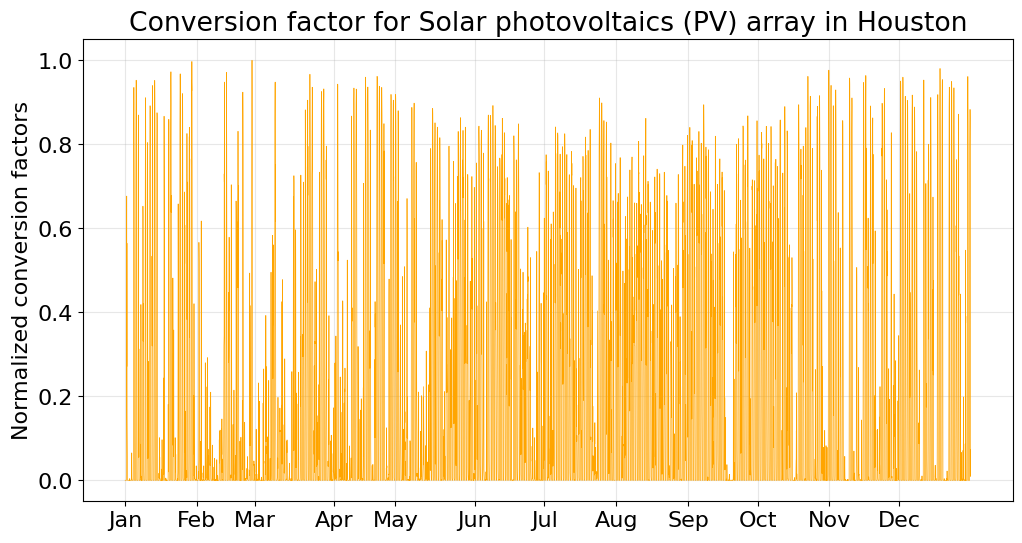

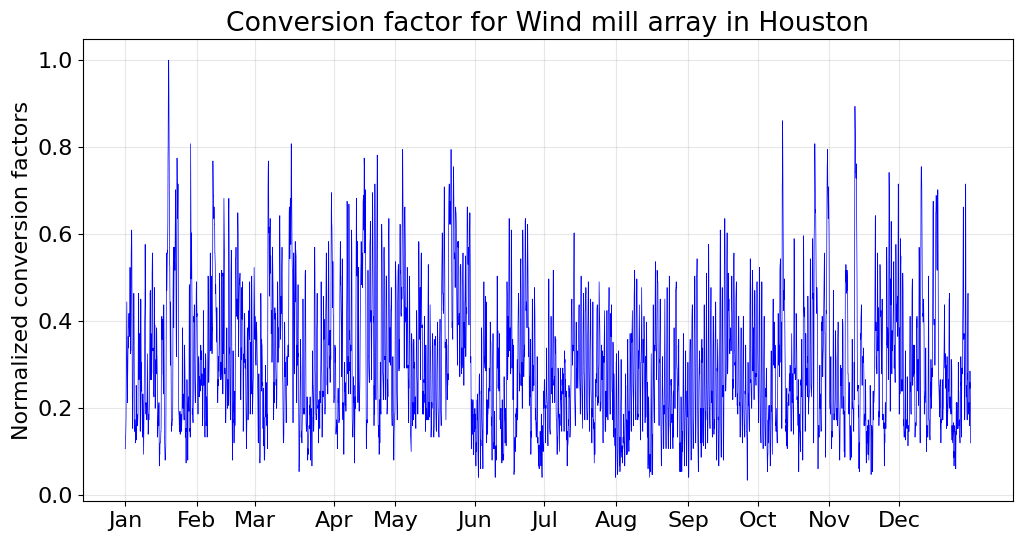

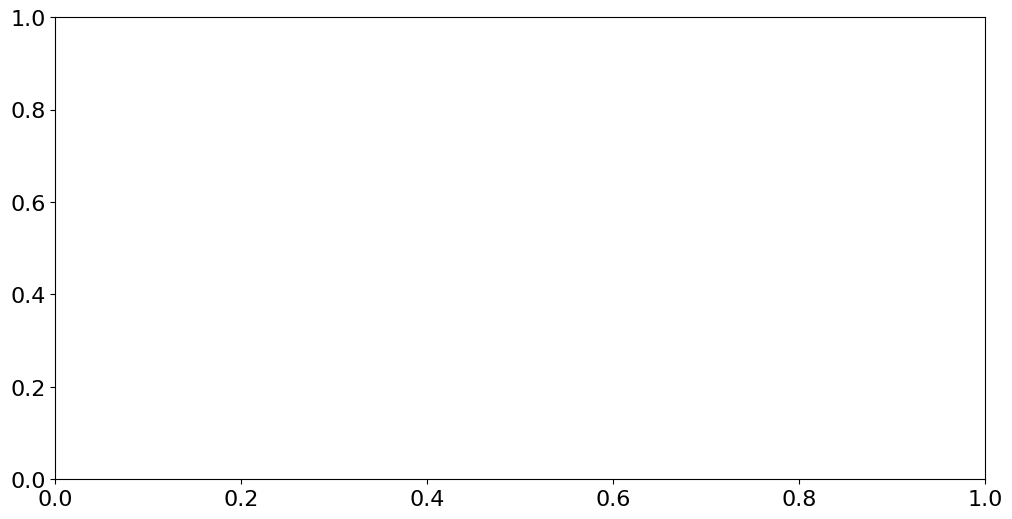

In [227]:
plot.capacity_factor(location= HO, process= PV, color= 'orange')
plot.capacity_factor(location= HO, process= WF, color= 'blue')
plot.cost_factor (location= HO, resource= CH4, color= 'red')

$\textit{Single location scenario}$

For a single location problem, the network can be declared as a single location.


In [248]:
case_sl = Scenario(name= 'shell', network= HO, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 1, label= 'shell milp case study (HO)')

In [249]:
reduced_case_sl = reduce_scenario(
    scenario=case_sl, location=HO, periods=20, scale_level=1, method=Clustermethod.agg_hierarchial)

$\textbf{Formulate model}$

A pyomo instance is formulated from the scenario

Concises sets and corresponding variables are declared.

Corresponding constraints are generated based on the nature of model chosen

In the presented example, a MILP is formulated



In [250]:
from pyomo.environ import ConcreteModel
from src.energiapy.model.pyomo_sets import generate_sets
from src.energiapy.model.pyomo_vars import *
from src.energiapy.model.pyomo_cons import *
from src.energiapy.model.pyomo_objs import cost_objective, uncertainty_cost_objective

def formulate_houston_milp(scenario: Scenario, carbon_bound:float= None, carbon_reduction_percentage:float= 0) -> ConcreteModel:
    """formulates a multi-scale mixed integer linear programming formulation of the scenario

    Args:
        scenario (Scenario): scenario under consideration

    Returns:
        ConcreteModel: pyomo model instance with sets, variables, constraints, objectives generated
    """

    instance = ConcreteModel()

    generate_sets(instance=instance, location_set=scenario.location_set, transport_set=scenario.transport_set, scales=scenario.scales,
                  process_set=scenario.process_set, resource_set=scenario.resource_set, material_set=scenario.material_set,
                  source_set=scenario.source_locations, sink_set=scenario.sink_locations)

    generate_scheduling_vars(
        instance=instance, scale_level=scenario.scheduling_scale_level)
    generate_network_vars(
        instance=instance, scale_level=scenario.network_scale_level)
    generate_network_binary_vars(
        instance=instance, scale_level=scenario.network_scale_level)

    if len(instance.locations) > 1:
        generate_transport_vars(
            instance=instance, scale_level=scenario.scheduling_scale_level)

    inventory_balance_constraint(instance=instance, scheduling_scale_level=scenario.scheduling_scale_level,
                                 conversion=scenario.conversion)
    nameplate_production_constraint(instance=instance, capacity_factor=scenario.capacity_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)
    nameplate_inventory_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level,
                                   scheduling_scale_level=scenario.scheduling_scale_level)
    resource_consumption_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict,
                                    cons_max=scenario.cons_max, scheduling_scale_level=scenario.scheduling_scale_level)
    resource_purchase_constraint(instance=instance, cost_factor=scenario.cost_factor, price=scenario.price,
                                 loc_res_dict=scenario.loc_res_dict, scheduling_scale_level=scenario.scheduling_scale_level,
                                 expenditure_scale_level=scenario.expenditure_scale_level)
    # resource_discharge_constraint(instance= instance, scheduling_scale_level= scenario.scheduling_scale_level)

    production_facility_constraint(instance=instance, prod_max=scenario.prod_max,
                                   loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    storage_facility_constraint(instance=instance, store_max=scenario.store_max,
                                loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)

    min_production_facility_constraint(instance=instance, prod_min=scenario.prod_min,
                                       loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    min_storage_facility_constraint(instance=instance, store_min=scenario.store_min,
                                    loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)

    location_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)

    network_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    process_capex_constraint(instance=instance, capex_dict=scenario.capex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_fopex_constraint(instance=instance, fopex_dict=scenario.fopex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_vopex_constraint(instance=instance, vopex_dict=scenario.vopex_dict,
                             network_scale_level=scenario.network_scale_level)

    process_land_constraint(instance=instance, land_dict=scenario.land_dict,
                            network_scale_level=scenario.network_scale_level)
    location_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    location_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    network_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    demand_constraint(instance=instance, demand_scale_level=scenario.demand_scale_level,
                      scheduling_scale_level=scenario.scheduling_scale_level, demand=scenario.demand)
    
    if carbon_bound is not None:
        carbon_emission_constraint(instance= instance, network_scale_level= scenario.network_scale_level, \
            carbon_reduction_percentage = carbon_reduction_percentage, carbon_bound = carbon_bound)

    # carbon_emission_location_constraint(instance= instance, network_scale_level= scenario.network_scale_level)
    # carbon_emission_network_constraint(instance= instance, network_scale_level= scenario.network_scale_level)
    

    cost_objective(instance=instance,
                   network_scale_level=scenario.network_scale_level)

    return instance



$\textit{Reduced single location model}$

In [251]:
reduced_milp_sl = formulate_houston_milp(scenario= reduced_case_sl)


$\textit{Single location scenario}$

In [252]:
results_HVG = solve(scenario = reduced_case_sl, instance= reduced_milp_sl, solver= 'gurobi', name=f"Mobility_HVG",\
    saveformat= '.pkl', print_solversteps = True)

Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 12572 rows, 8734 columns and 35415 nonzeros
Model fingerprint: 0xbcf491ca
Variable types: 8724 continuous, 10 integer (10 binary)
Coefficient statistics:
  Matrix range     [4e-04, 1e+20]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+03, 1e+20]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 7380 rows and 4695 columns
Presolve time: 0.03s
Presolved: 5192 rows, 4039 columns, 14798 nonzeros
Variable types: 4034 continuous, 5 integer (5 binary)

Root relaxation: objective 4.536605e+08, 1976 iterations, 0.12 seconds (0.17 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    4.536

$\textit{Reduced single location scenario}$

$\textbf{Graphing results}$

$\textit{Scheduling results}$

Can be generated at the index of the variable for any component at any location

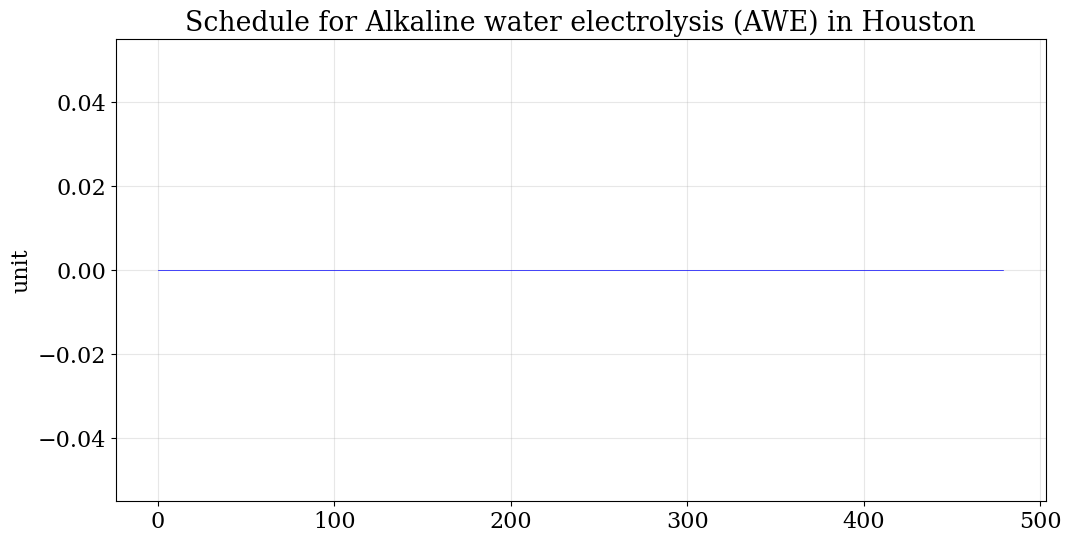

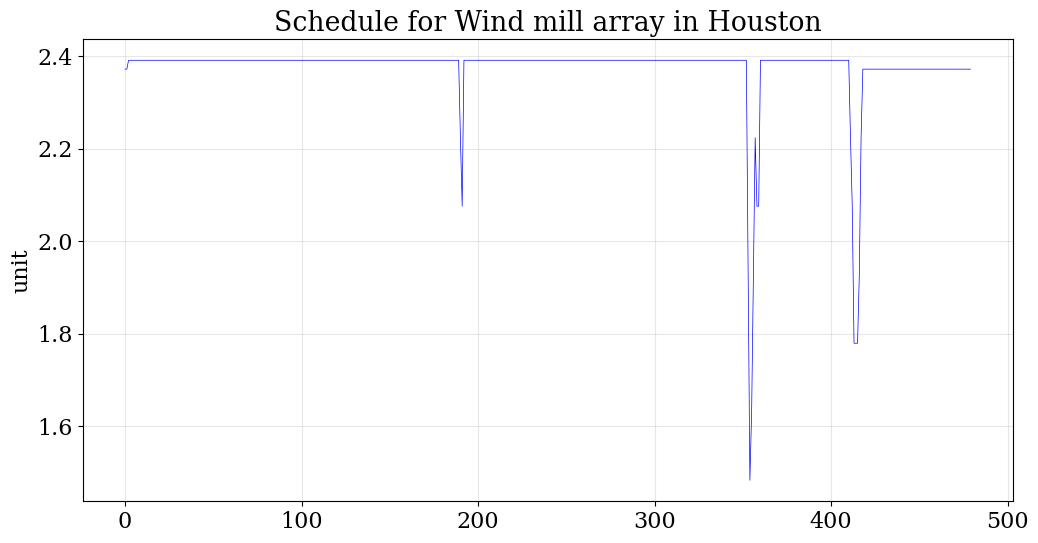

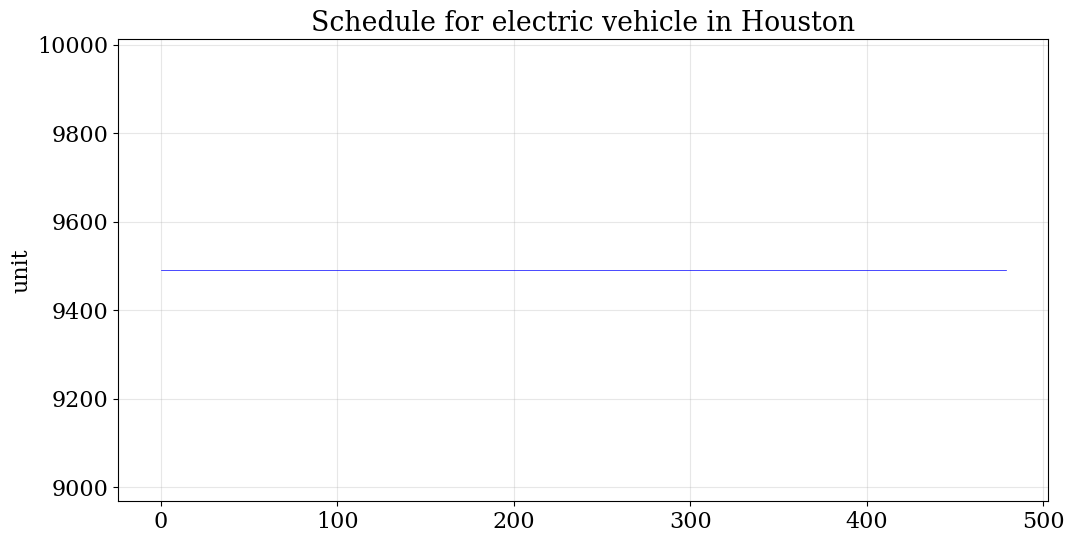

In [253]:
plot.schedule(results=results_EV, y_axis='P',
               component='AKE', location='HO')

plot.schedule(results=results_EV, y_axis='P',
               component='WF', location='HO')

plot.schedule(results=results_EV, y_axis='P',
               component='EV', location='HO')



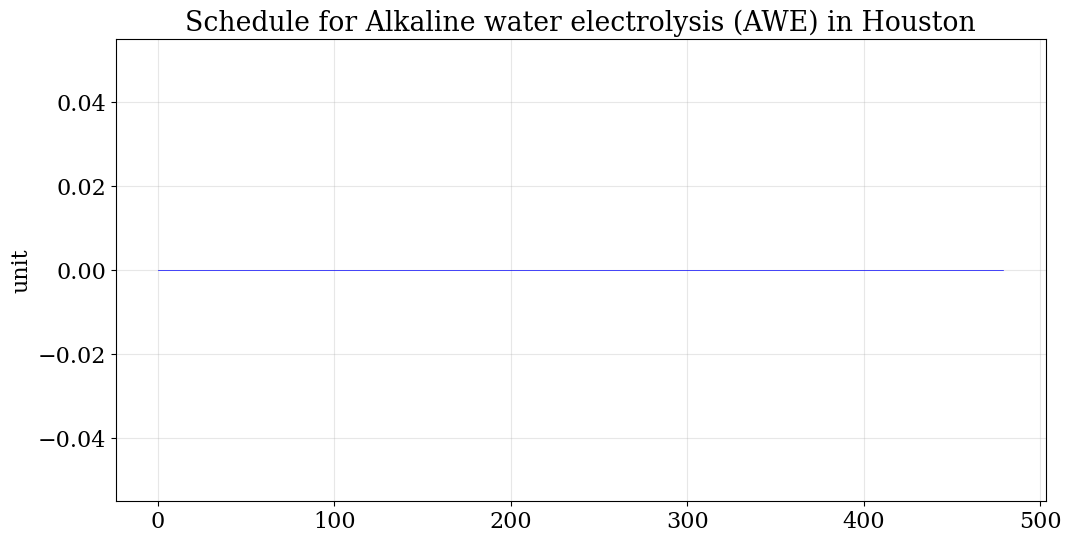

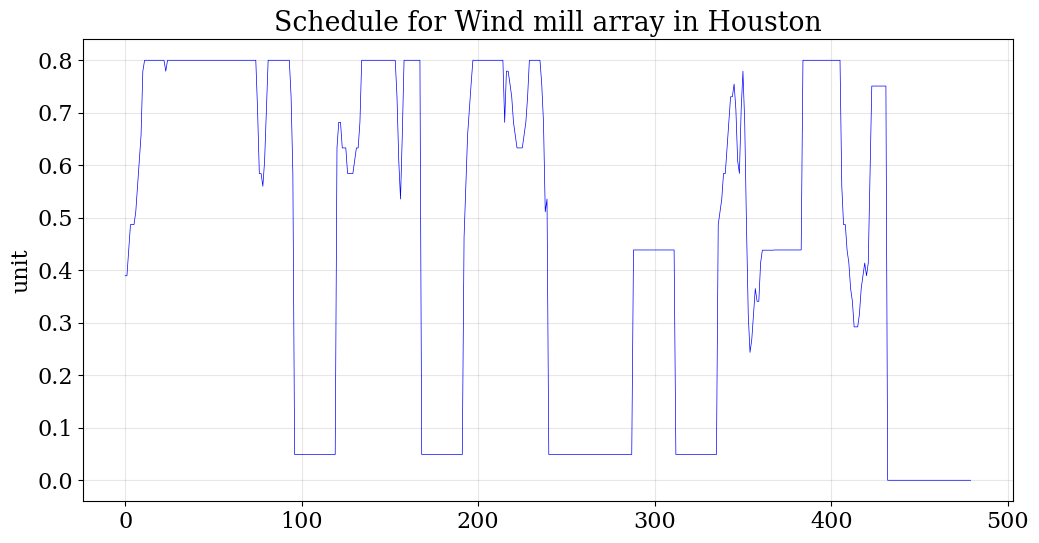

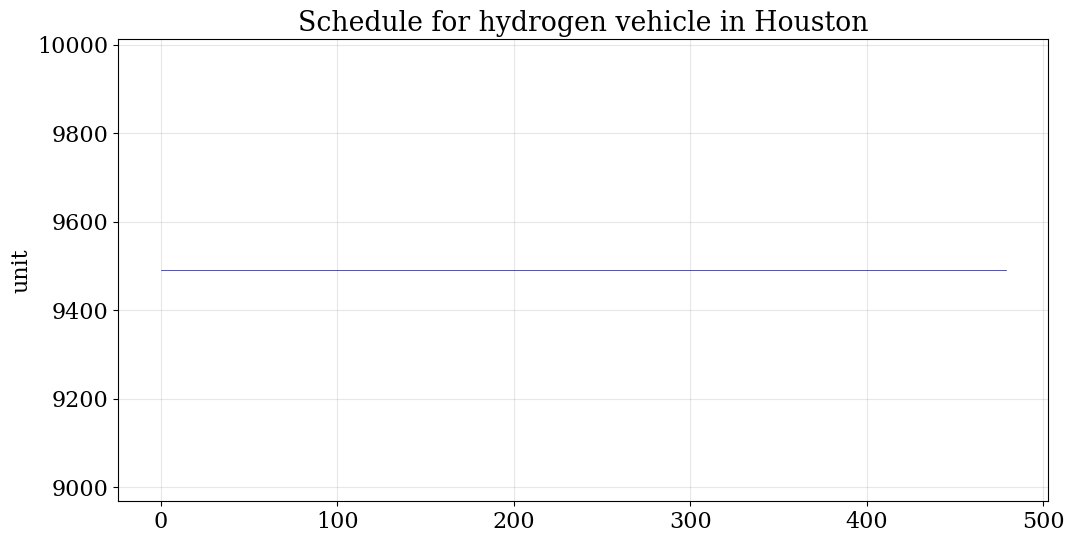

In [156]:
plot.schedule(results=results_HV, y_axis='P',
               component='AKE', location='HO')

plot.schedule(results=results_HV, y_axis='P',
               component='WF', location='HO')

plot.schedule(results=results_HV, y_axis='P',
               component='HV', location='HO')

$\textit{Contribution}$

The contribution of different components to a particular variable value can be visualized

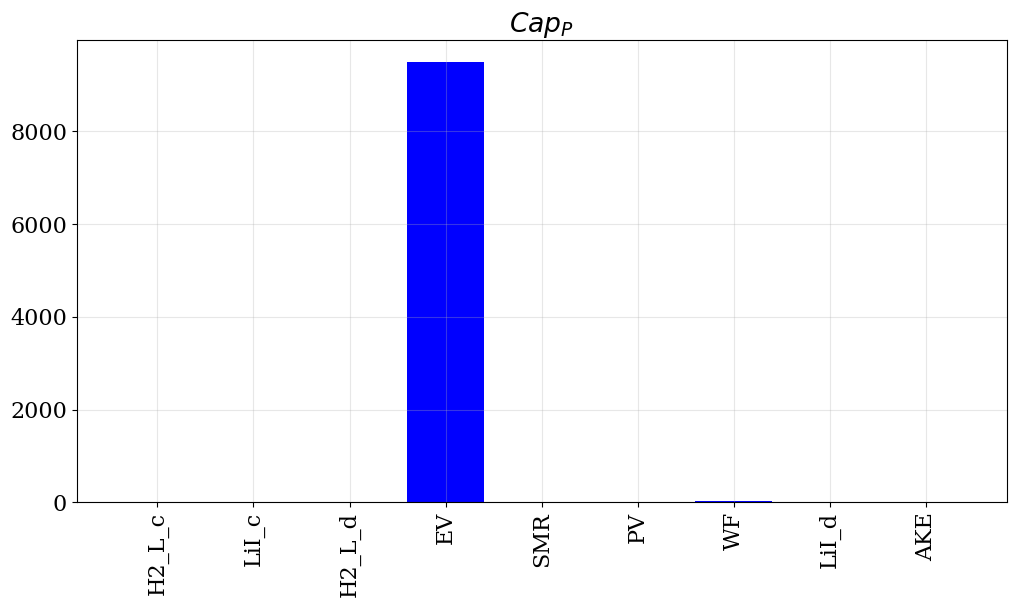

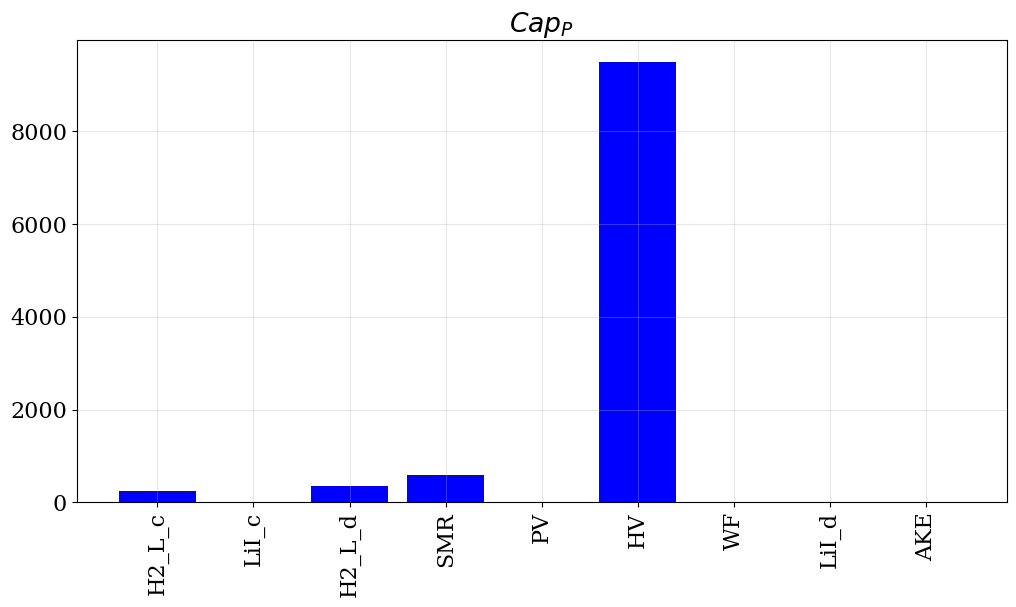

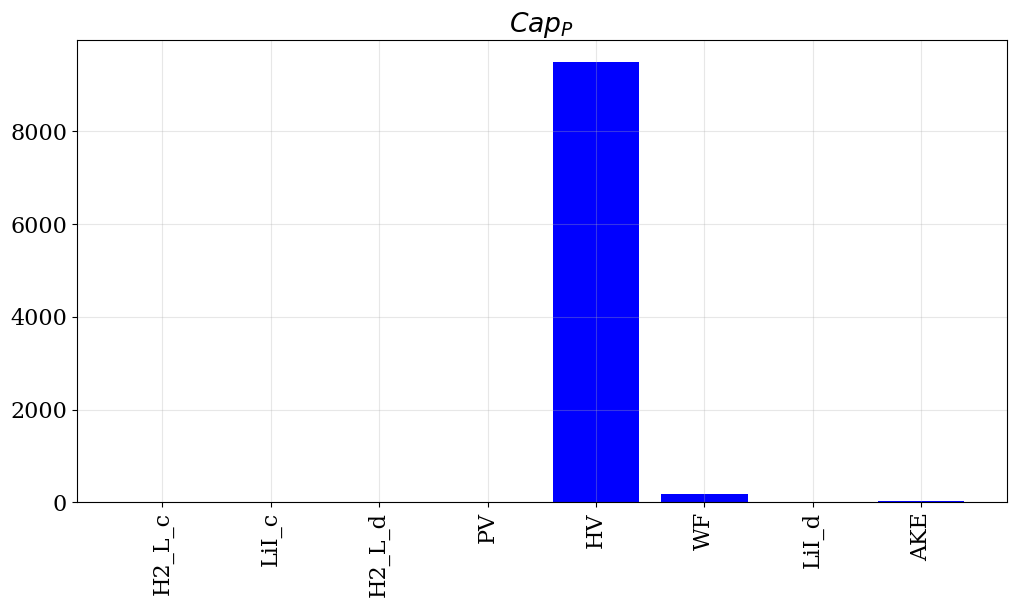

In [254]:

# plot.contribution(results=results_EV, y_axis='P_location', location='HO')
# plot.contribution(results=results_HV, y_axis='P_location', location='HO')
# plot.contribution(results=results_EV, y_axis='S_location', location='HO')
# plot.contribution(results=results_HV, y_axis='S_location', location='HO')
# plot.contribution(results=results_EV, y_axis='B_location', location='HO')
# plot.contribution(results=results_HV, y_axis='B_location', location='HO')
plot.contribution(results=results_EV, y_axis='Cap_P', location='HO')
plot.contribution(results=results_HG, y_axis='Cap_P', location='HO')
plot.contribution(results=results_HVG, y_axis='Cap_P', location='HO')


# plot.contribution(results=results_EV, y_axis='Cap_S', location='HO')
# plot.contribution(results=results_HV, y_axis='Cap_S', location='HO')
# # graph.contribution(results=results_sl, y_axis='P_location', location='HO')


In [255]:
results_EV.output['objective'], results_HV.output['objective'], results_HVG.output['objective']


(113243318.23141393, 96223526.06174822, 453660461.8372531)

In [256]:
results_EV.output['S_network'][('CO2_Vent', 0)], results_HV.output['S_network'][('CO2_Vent', 0)], results_HVG.output['S_network'][('CO2_Vent', 0)]


KeyError: ('CO2_Vent', 0)

In [282]:
results_HV.output['S_network'][('CO2_Vent', 0)]

12525558.65027708

In [239]:
9.49*10**3*365/ results_EV.output['objective']

0.030587676642621735

In [240]:
9.49*10**3*365/ results_HV.output['objective']

0.0359979533256471

In [259]:
9.49*10**4*365/ results_HVG.output['objective']

0.0763533587646575

In [268]:
results_dict = {
    'EV': {'lcpm': 0.030587676642621735, 'c': 'steelblue', 'label': 'Electricity'},
    'HV': {'lcpm': 0.0359979533256471, 'c': 'indianred', 'label': 'Hydrogen - Blue'},
    'HVG': {'lcpm': 0.0763533587646575, 'c': 'green', 'label': 'Hydrogen - Green'},
    
    
}

In [272]:
lcpm = [results_dict[i]['lcpm'] for i in results_dict.keys()]
color = [results_dict[i]['c'] for i in results_dict.keys()]
labels = [results_dict[i]['label'] for i in results_dict.keys()]



(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

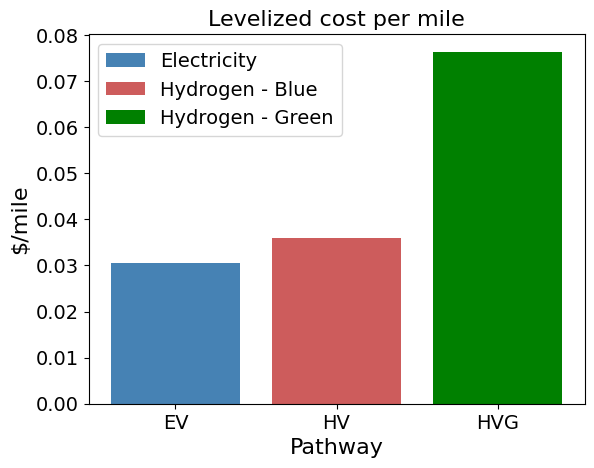

In [285]:
for i in range(3):
    plt.bar(list(results_dict.keys())[i], lcpm[i], color = color[i], label = labels[i])
plt.legend(fontsize = 14)
plt.title('Levelized cost per mile', fontsize = 16)
plt.xlabel('Pathway', fontsize = 16)
plt.ylabel('$/mile', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)




In [283]:
9.49*10**3*365/12525558.65027708

0.27654255564268787